元データの確認
              sp500         DGS10
count  14734.000000  14734.000000
mean       0.000315      0.000026
std        0.010551      0.066901
min       -0.204669     -0.750000
25%       -0.004514     -0.030000
50%        0.000463      0.000000
75%        0.005419      0.030000
max        0.107890      0.650000

sp500 の NaN 数: 0
DGS10 の NaN 数: 0

S&P500 return の fat tail 分析
データ数: 14734
平均: 0.00031465
標準偏差: 0.01055123
歪度: -0.67914439
尖度: 21.80854067
超過尖度: 18.80854067
判定: 正規分布より裾が厚い可能性があります。

|x - mean| > 3σ の実データ割合: 0.01357405
正規分布での理論値: 0.00269980
実データ / 正規分布: 5.03 倍

|変動| 上位5%閾値: 0.02050935
|変動| 上位1%閾値: 0.03508343



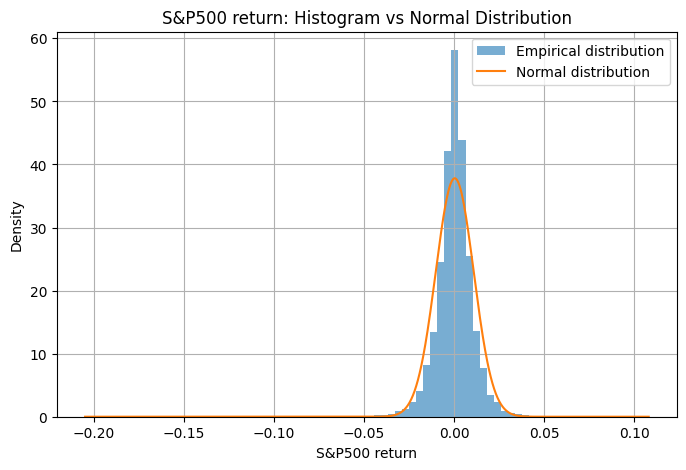

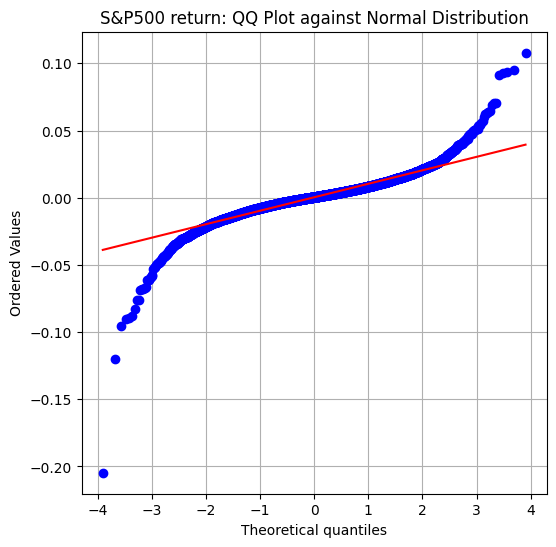

DGS10 yield change の fat tail 分析
データ数: 14734
平均: 0.00002647
標準偏差: 0.06690057
歪度: -0.23262240
尖度: 11.39513208
超過尖度: 8.39513208
判定: 正規分布より裾が厚い可能性があります。

|x - mean| > 3σ の実データ割合: 0.01513506
正規分布での理論値: 0.00269980
実データ / 正規分布: 5.61 倍

|変動| 上位5%閾値: 0.14000000
|変動| 上位1%閾値: 0.23000000



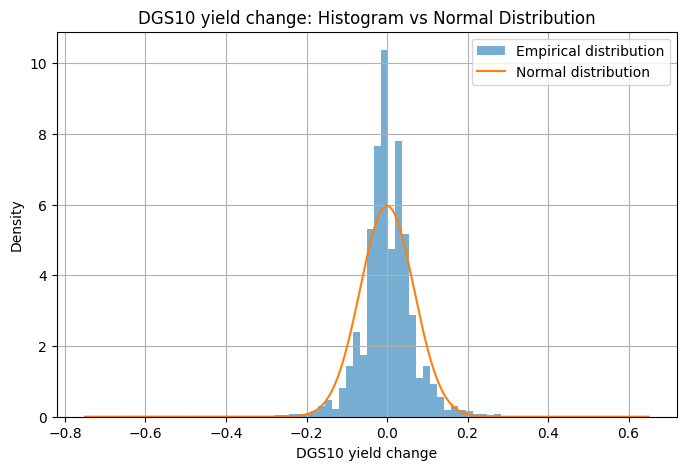

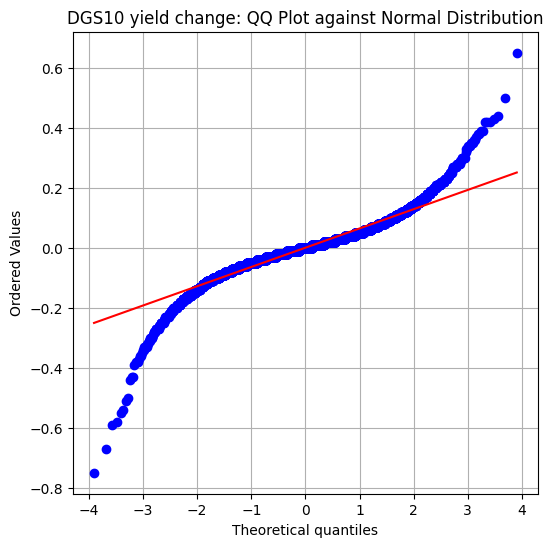

分析結果まとめ
                 name      n      mean       std      skew   kurtosis  \
0       S&P500 return  14734  0.000315  0.010551 -0.679144  21.808541   
1  DGS10 yield change  14734  0.000026  0.066901 -0.232622  11.395132   

   excess_kurtosis  empirical_3sigma_probability  normal_3sigma_probability  \
0        18.808541                      0.013574                     0.0027   
1         8.395132                      0.015135                     0.0027   

   ratio_to_normal_3sigma   abs_q95   abs_q99  
0                5.027804  0.020509  0.035083  
1                5.606002  0.140000  0.230000  


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, probplot

# 単一時系列データを対象

# ============================================================
# 1. データ読み込み
# ============================================================

df = pd.read_csv("data/train_sp500_us10y.csv")

# 日付処理
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")
df = df.set_index("date")

# 数値変換
# 数値に変換できない値は NaN にする
df["sp500"] = pd.to_numeric(df["sp500"], errors="coerce")
df["DGS10"] = pd.to_numeric(df["DGS10"], errors="coerce")


# ============================================================
# 2. データ確認
# ============================================================

print("元データの確認")
print(df[["sp500", "DGS10"]].describe())
print()

print("sp500 の NaN 数:", df["sp500"].isna().sum())
print("DGS10 の NaN 数:", df["DGS10"].isna().sum())
print()


# ============================================================
# 3. 分析用系列の作成
# ============================================================

# sp500 はすでに S&P500 リターンなので、そのまま使う
df["sp500_return"] = df["sp500"]

# DGS10 はすでに利回り差分[%]なので、そのまま使う
df["dgs10_change"] = df["DGS10"]

# inf, -inf を NaN にして除去
data = (
    df[["sp500_return", "dgs10_change"]]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
)


# ============================================================
# 4. 単一時系列の fat tail 分析関数
# ============================================================

def analyze_single_fattail(series, name, bins=80):
    """
    単一時系列の fat tail 性を確認する関数

    確認するもの:
    - 平均
    - 標準偏差
    - 歪度
    - 尖度
    - 超過尖度
    - 3σ超過確率
    - 正規分布との比較
    - ヒストグラム
    - QQプロット
    """

    r = series.replace([np.inf, -np.inf], np.nan).dropna()

    if len(r) == 0:
        print(f"{name}: 有効なデータがありません")
        return None

    mean = r.mean()
    std = r.std()

    if std == 0 or np.isnan(std):
        print(f"{name}: 標準偏差が0またはNaNなので分析できません")
        return None

    skew = r.skew()

    # pandas の kurtosis() は「超過尖度」を返す
    # 正規分布の場合、超過尖度 = 0
    excess_kurtosis = r.kurtosis()
    kurtosis = excess_kurtosis + 3

    print("=" * 70)
    print(f"{name} の fat tail 分析")
    print("=" * 70)

    print(f"データ数: {len(r)}")
    print(f"平均: {mean:.8f}")
    print(f"標準偏差: {std:.8f}")
    print(f"歪度: {skew:.8f}")
    print(f"尖度: {kurtosis:.8f}")
    print(f"超過尖度: {excess_kurtosis:.8f}")

    if excess_kurtosis > 0:
        print("判定: 正規分布より裾が厚い可能性があります。")
    else:
        print("判定: 尖度だけを見ると、強い fat tail は確認しにくいです。")

    print()

    # ------------------------------------------------------------
    # 3σ超過確率
    # ------------------------------------------------------------

    empirical_3sigma = (np.abs(r - mean) > 3 * std).mean()

    # 正規分布では |X - μ| > 3σ は約0.27%
    normal_3sigma = 2 * (1 - norm.cdf(3))

    print(f"|x - mean| > 3σ の実データ割合: {empirical_3sigma:.8f}")
    print(f"正規分布での理論値: {normal_3sigma:.8f}")

    if normal_3sigma > 0:
        print(f"実データ / 正規分布: {empirical_3sigma / normal_3sigma:.2f} 倍")

    print()

    # ------------------------------------------------------------
    # 上位5%, 1%の絶対変動閾値
    # ------------------------------------------------------------

    abs_r = np.abs(r)

    q95 = abs_r.quantile(0.95)
    q99 = abs_r.quantile(0.99)

    print(f"|変動| 上位5%閾値: {q95:.8f}")
    print(f"|変動| 上位1%閾値: {q99:.8f}")

    print()

    # ------------------------------------------------------------
    # ヒストグラム + 正規分布
    # ------------------------------------------------------------

    x = np.linspace(r.min(), r.max(), 1000)

    plt.figure(figsize=(8, 5))
    plt.hist(
        r,
        bins=bins,
        density=True,
        alpha=0.6,
        label="Empirical distribution"
    )
    plt.plot(
        x,
        norm.pdf(x, mean, std),
        label="Normal distribution"
    )
    plt.title(f"{name}: Histogram vs Normal Distribution")
    plt.xlabel(name)
    plt.ylabel("Density")
    plt.legend()
    plt.grid(True)
    plt.show()

    # ------------------------------------------------------------
    # QQプロット
    # ------------------------------------------------------------

    plt.figure(figsize=(6, 6))
    probplot(r, dist="norm", plot=plt)
    plt.title(f"{name}: QQ Plot against Normal Distribution")
    plt.grid(True)
    plt.show()

    # 結果を辞書で返す
    result = {
        "name": name,
        "n": len(r),
        "mean": mean,
        "std": std,
        "skew": skew,
        "kurtosis": kurtosis,
        "excess_kurtosis": excess_kurtosis,
        "empirical_3sigma_probability": empirical_3sigma,
        "normal_3sigma_probability": normal_3sigma,
        "ratio_to_normal_3sigma": empirical_3sigma / normal_3sigma,
        "abs_q95": q95,
        "abs_q99": q99,
    }

    return result


# ============================================================
# 5. 実行
# ============================================================

sp500_result = analyze_single_fattail(
    data["sp500_return"],
    "S&P500 return"
)

dgs10_result = analyze_single_fattail(
    data["dgs10_change"],
    "DGS10 yield change"
)


# ============================================================
# 6. 結果を表として確認
# ============================================================

results = pd.DataFrame([sp500_result, dgs10_result])

print("=" * 70)
print("分析結果まとめ")
print("=" * 70)
print(results)

In [ ]:
# ============================================================
# 7. 生成データ mixed_sabr / mixed_brown の fat tail 確認
#    - 標準出力を log.txt に保存
#    - 集計結果を CSV に保存
#    - 各系列のグラフを PNG に保存
# ============================================================

from pathlib import Path
from contextlib import redirect_stdout
import re
import pandas as pd
import matplotlib.pyplot as plt


def resolve_data_path(filename):
    """Notebookの実行場所がプロジェクト直下でもstylizedfacts-直下でも動くようにする。"""
    candidates = [
        Path(filename),
        Path("data") / filename,
        Path("stylizedfacts-") / "data" / filename,
    ]

    for path in candidates:
        if path.exists():
            return path

    raise FileNotFoundError(f"{filename} が見つかりません: {candidates}")


def safe_filename(name):
    """ファイル名に使いにくい文字を置換する。"""
    return re.sub(r"[^a-zA-Z0-9_\-\.]", "_", str(name))


def analyze_generated_fattail(csv_path, dataset_name, bins=80, fig_dir=None):
    """
    mixedデータ内の mask*_sp500 / mask*_DGS10 を1系列ずつ fat tail 分析する。
    
    - analyze_single_fattail() の標準出力は呼び出し側でlogに保存される
    - analyze_single_fattail() が描画したグラフは系列ごとにPNG保存する
    - 返り値は各系列の統計量をまとめたDataFrame
    """
    generated_df = pd.read_csv(csv_path)

    # 数値化できない値はNaNにして、分析関数側で除去する
    generated_df = generated_df.apply(pd.to_numeric, errors="coerce")

    target_columns = [
        col for col in generated_df.columns
        if col.endswith("_sp500") or col.endswith("_DGS10")
    ]

    if fig_dir is not None:
        fig_dir = Path(fig_dir)
        fig_dir.mkdir(parents=True, exist_ok=True)

    generated_results = []

    for col in target_columns:
        title = f"{dataset_name}: {col}"

        before_fig_nums = set(plt.get_fignums())
        original_show = plt.show

        try:
            # 保存用の実行では show() でfigureが閉じられないようにする
            if fig_dir is not None:
                plt.show = lambda *args, **kwargs: None

            result = analyze_single_fattail(
                generated_df[col],
                title,
                bins=bins,
            )
        finally:
            plt.show = original_show

        # analyze_single_fattail() 内で作成されたグラフをすべて保存
        if fig_dir is not None:
            new_fig_nums = [
                num for num in plt.get_fignums()
                if num not in before_fig_nums
            ]
            figure_labels = ["histogram_vs_normal", "qq_plot"]

            if not new_fig_nums:
                print(f"Warning: no figure was created for {title}")

            for idx, fig_num in enumerate(new_fig_nums, start=1):
                fig = plt.figure(fig_num)
                label = figure_labels[idx - 1] if idx <= len(figure_labels) else f"figure_{idx}"
                fig_path = fig_dir / (
                    f"{safe_filename(dataset_name)}_{safe_filename(col)}_{label}.png"
                )
                fig.savefig(fig_path, dpi=300, bbox_inches="tight")
                plt.close(fig)

                print(f"Saved figure: {fig_path}")

        if result is not None:
            result["dataset"] = dataset_name
            result["column"] = col
            generated_results.append(result)

    return pd.DataFrame(generated_results)


# ============================================================
# 出力先の設定
# ============================================================

output_dir = Path("results")
output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = output_dir / "figures_generated_fattail"
fig_dir.mkdir(parents=True, exist_ok=True)

log_path = output_dir / "generated_fattail_log.txt"
csv_output_path = output_dir / "generated_fattail_summary.csv"


# ============================================================
# 分析実行
# ============================================================

with open(log_path, "w", encoding="utf-8") as f:
    with redirect_stdout(f):

        print("=" * 70)
        print("生成データ mixed_sabr / mixed_brown の fat tail 分析")
        print("=" * 70)

        mixed_sabr_path = resolve_data_path("mixed_sabr_masked.csv")
        mixed_brown_path = resolve_data_path("mixed_brown_masked.csv")

        print(f"mixed_sabr path : {mixed_sabr_path}")
        print(f"mixed_brown path: {mixed_brown_path}")
        print()

        mixed_sabr_results = analyze_generated_fattail(
            mixed_sabr_path,
            "mixed_sabr",
            bins=80,
            fig_dir=fig_dir,
        )

        mixed_brown_results = analyze_generated_fattail(
            mixed_brown_path,
            "mixed_brown",
            bins=80,
            fig_dir=fig_dir,
        )

        mixed_results = pd.concat(
            [mixed_sabr_results, mixed_brown_results],
            ignore_index=True,
        )

        summary_columns = [
            "dataset",
            "column",
            "n",
            "mean",
            "std",
            "skew",
            "kurtosis",
            "excess_kurtosis",
            "empirical_3sigma_probability",
            "ratio_to_normal_3sigma",
            "abs_q95",
            "abs_q99",
        ]

        summary_df = mixed_results[summary_columns]

        print()
        print("=" * 70)
        print("生成データ fat tail 分析結果まとめ")
        print("=" * 70)
        print(summary_df.to_string(index=False))


# ============================================================
# CSV保存
# ============================================================

summary_df.to_csv(
    csv_output_path,
    index=False,
    encoding="utf-8-sig",
)


# ============================================================
# Notebook上にも結果を表示
# ============================================================

print(f"ログを保存しました: {log_path}")
print(f"CSVを保存しました: {csv_output_path}")
print(f"グラフを保存しました: {fig_dir}")

display(summary_df)